In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("../data/processed")

file_path = (
    PROCESSED_DIR
    / "seoul_apartment_rental_2023_2025_clean.csv"
)

df = pd.read_csv(
    file_path,
    parse_dates=["contract_date"]
)

df.shape

(881794, 25)

In [2]:
df[
    [
        "contract_date",
        "contract_year",
        "contract_month",
        "자치구명",
        "전월세구분",
        "임대면적",
        "보증금(만원)",
        "임대료(만원)",
        "건축년도",
        "building_age"
    ]
].head()

,contract_date,contract_year,contract_month,자치구명,전월세구분,임대면적,보증금(만원),임대료(만원),건축년도,building_age
0,2023-05-15,2023,5,중랑구,전세,84.71,46000,0,2003.0,20.0
1,2023-05-15,2023,5,중랑구,전세,101.97,46500,0,2003.0,20.0
2,2023-05-15,2023,5,양천구,전세,133.03,70000,0,2004.0,19.0
3,2023-05-15,2023,5,중랑구,전세,84.94,37500,0,2006.0,17.0
4,2023-05-15,2023,5,성동구,전세,84.98,70000,0,2012.0,11.0


In [3]:
df.dtypes

접수년도                                int64
자치구명                                  str
법정동명                                  str
층                                 float64
계약일                                 int64
전월세구분                                 str
임대면적                              float64
보증금(만원)                             int64
임대료(만원)                             int64
건물명                                   str
건축년도                              float64
건물용도                                  str
계약기간                                  str
신규계약구분                                str
source_file                           str
valid_monthly_rent                   bool
has_build_year                       bool
contract_date              datetime64[us]
contract_year                       int64
contract_month                      int64
building_age                      float64
pyeong                            float64
deposit_per_m2                    float64
building_age_raw                  

In [4]:
print("데이터 크기:", df.shape)

print("최초 계약일:", df["contract_date"].min())
print("최종 계약일:", df["contract_date"].max())

print("\n계약연도별 건수")
print(
    df["contract_year"]
    .value_counts()
    .sort_index()
)

데이터 크기: (881794, 25)
최초 계약일: 2022-11-05 00:00:00
최종 계약일: 2026-02-02 00:00:00

계약연도별 건수
contract_year
2022      5840
2023    235725
2024    217001
2025    423199
2026        29
Name: count, dtype: int64


In [5]:
outside_period = df[
    (df["contract_date"] < "2023-01-01")
    | (df["contract_date"] > "2025-12-31")
]

print("분석기간 외 데이터:", len(outside_period))

outside_period[
    [
        "접수년도",
        "contract_date",
        "자치구명",
        "건물명",
        "전월세구분",
        "보증금(만원)",
        "임대료(만원)"
    ]
].head(20)

분석기간 외 데이터: 5869


,접수년도,contract_date,자치구명,건물명,전월세구분,보증금(만원),임대료(만원)
7,2023,2022-12-28,영등포구,(1101-1),전세,11500,0
13,2023,2022-12-25,서초구,(1617-21),월세,5000,290
30,2023,2022-11-30,중구,(73-1),월세,10000,19
39,2023,2022-12-28,중랑구,(506-14),월세,1000,46
41,2023,2022-11-28,서대문구,DMC금호리첸시아,월세,20000,190
43,2023,2022-11-19,서대문구,DMC에코자이,월세,40000,26
44,2023,2022-11-28,서대문구,DMC래미안클라시스,전세,20000,0
47,2023,2022-11-26,서대문구,DMC센트럴아이파크,월세,20000,170
48,2023,2022-12-02,은평구,DMC롯데캐슬더퍼스트,월세,10000,210
50,2023,2022-11-30,서대문구,DMC센트럴아이파크,전세,70000,0


In [6]:
df_eda = df[
    (df["contract_date"] >= "2023-01-01")
    & (df["contract_date"] <= "2025-12-31")
].copy()

df_eda.shape

(875925, 25)

In [7]:
print("전체 정제 데이터:", len(df))
print("EDA 대상 데이터:", len(df_eda))
print("분석기간 제외:", len(df) - len(df_eda))

print("\n계약연도별 거래 건수")
print(
    df_eda["contract_year"]
    .value_counts()
    .sort_index()
)

전체 정제 데이터: 881794
EDA 대상 데이터: 875925
분석기간 제외: 5869

계약연도별 거래 건수
contract_year
2023    235725
2024    217001
2025    423199
Name: count, dtype: int64


In [8]:
year_rent_counts = (
    df_eda
    .groupby(["contract_year", "전월세구분"])
    .size()
    .unstack(fill_value=0)
)

year_rent_counts

전월세구분,월세,전세
contract_year,,
2023,94948,140777
2024,90885,126116
2025,184607,238592


In [9]:
year_rent_counts["전체"] = year_rent_counts.sum(axis=1)

year_rent_counts

전월세구분,월세,전세,전체
contract_year,,,
2023,94948,140777,235725
2024,90885,126116,217001
2025,184607,238592,423199


In [10]:
year_rent_ratio = (
    year_rent_counts[["전세", "월세"]]
    .div(year_rent_counts["전체"], axis=0)
    * 100
)

year_rent_ratio.round(2)

전월세구분,전세,월세
contract_year,,
2023,59.72,40.28
2024,58.12,41.88
2025,56.38,43.62


In [12]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

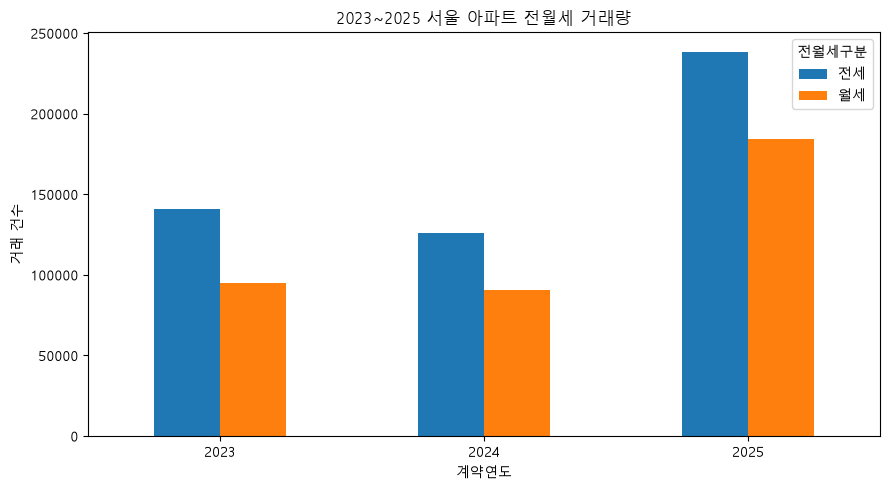

In [13]:
ax = year_rent_counts[["전세", "월세"]].plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("2023~2025 서울 아파트 전월세 거래량")
ax.set_xlabel("계약연도")
ax.set_ylabel("거래 건수")
ax.legend(title="전월세구분")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

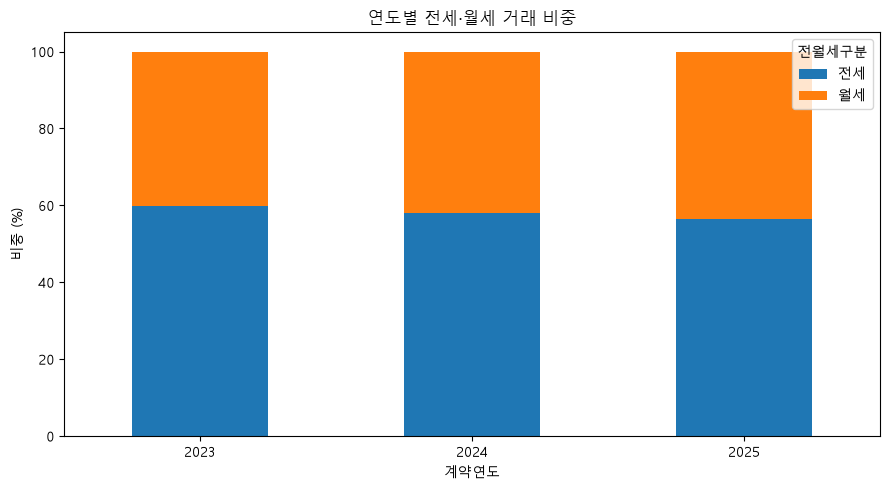

In [14]:
ax = year_rent_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

ax.set_title("연도별 전세·월세 거래 비중")
ax.set_xlabel("계약연도")
ax.set_ylabel("비중 (%)")
ax.legend(title="전월세구분")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
df_eda["year_month"] = (
    df_eda["contract_date"]
    .dt.to_period("M")
    .astype(str)
)

In [16]:
monthly_counts = (
    df_eda
    .groupby(["year_month", "전월세구분"])
    .size()
    .unstack(fill_value=0)
)

monthly_counts["전체"] = monthly_counts.sum(axis=1)

monthly_counts

전월세구분,월세,전세,전체
year_month,,,
2023-01,7577,9857,17434
2023-02,10092,13018,23110
2023-03,8819,14147,22966
2023-04,7752,12183,19935
2023-05,8312,11523,19835
2023-06,7699,11181,18880
2023-07,6986,10997,17983
2023-08,7144,11278,18422
2023-09,7149,10848,17997


In [17]:
print("월 개수:", len(monthly_counts))
print("최초 월:", monthly_counts.index.min())
print("최종 월:", monthly_counts.index.max())

월 개수: 36
최초 월: 2023-01
최종 월: 2025-12


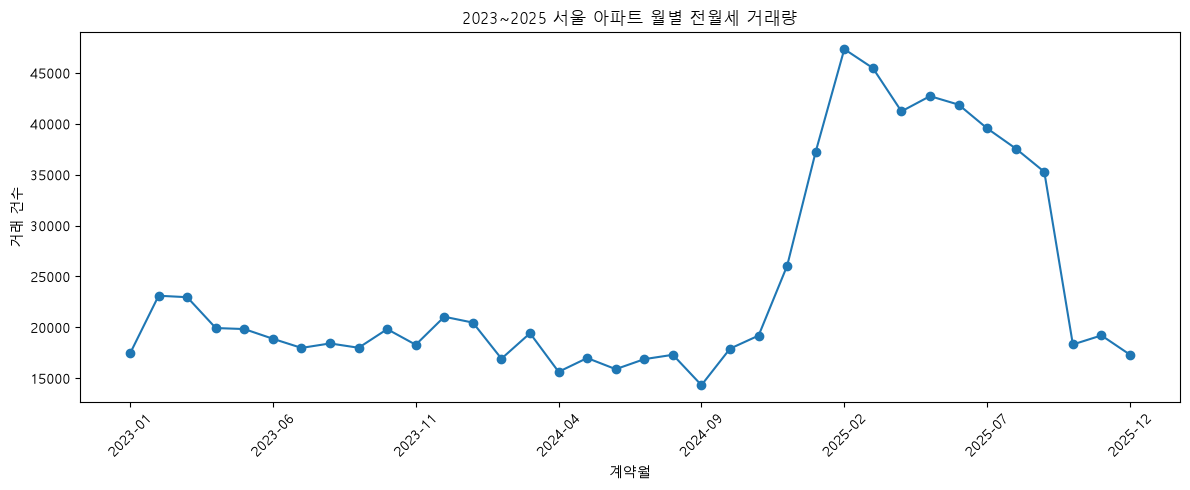

In [18]:
ax = monthly_counts["전체"].plot(
    figsize=(12, 5),
    marker="o"
)

ax.set_title("2023~2025 서울 아파트 월별 전월세 거래량")
ax.set_xlabel("계약월")
ax.set_ylabel("거래 건수")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

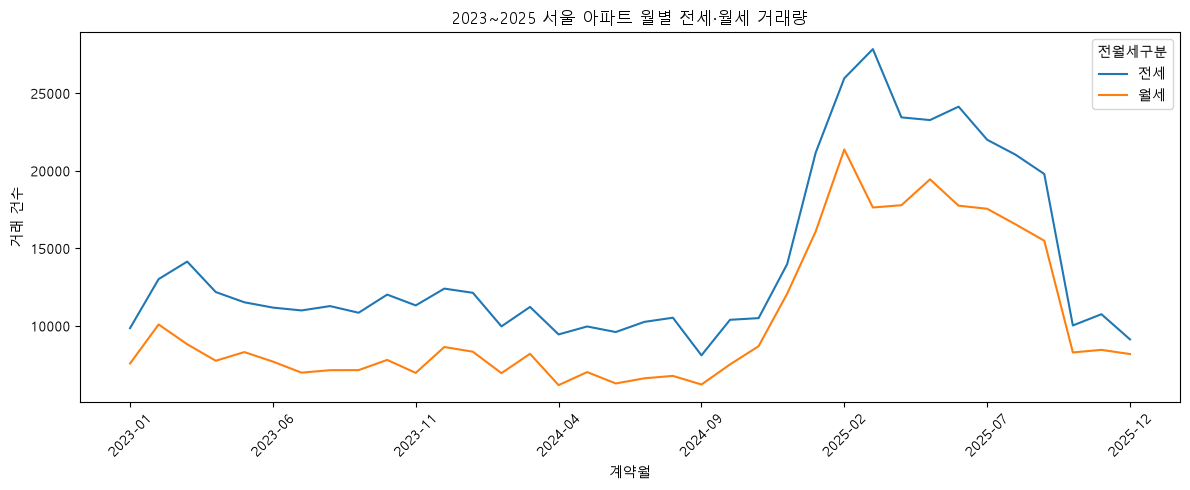

In [19]:
ax = monthly_counts[["전세", "월세"]].plot(
    figsize=(12, 5)
)

ax.set_title("2023~2025 서울 아파트 월별 전세·월세 거래량")
ax.set_xlabel("계약월")
ax.set_ylabel("거래 건수")
ax.legend(title="전월세구분")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
monthly_avg_by_year = (
    monthly_counts
    .copy()
)

monthly_avg_by_year["contract_year"] = (
    monthly_avg_by_year.index.str[:4].astype(int)
)

monthly_avg_by_year.groupby("contract_year")[
    ["전세", "월세", "전체"]
].mean().round(1)

전월세구분,전세,월세,전체
contract_year,,,
2023,11731.4,7912.3,19643.8
2024,10509.7,7573.8,18083.4
2025,19882.7,15383.9,35266.6


In [21]:
monthly_counts.head(12)

전월세구분,월세,전세,전체
year_month,,,
2023-01,7577,9857,17434
2023-02,10092,13018,23110
2023-03,8819,14147,22966
2023-04,7752,12183,19935
2023-05,8312,11523,19835
2023-06,7699,11181,18880
2023-07,6986,10997,17983
2023-08,7144,11278,18422
2023-09,7149,10848,17997


In [22]:
monthly_counts.tail(12)

전월세구분,월세,전세,전체
year_month,,,
2025-01,16094,21178,37272
2025-02,21375,25968,47343
2025-03,17636,27846,45482
2025-04,17782,23446,41228
2025-05,19451,23273,42724
2025-06,17752,24137,41889
2025-07,17553,22003,39556
2025-08,16543,21033,37576
2025-09,15491,19795,35286


In [23]:
pd.crosstab(
    df_eda["source_file"],
    df_eda["contract_year"]
)

contract_year,2023,2024,2025
source_file,,,
서울특별시_전월세가_2023.csv,227961,48,0
서울특별시_전월세가_2024.csv,7153,195749,66
서울특별시_전월세가_2025.csv,611,21204,423133


In [24]:
monthly_avg_by_year = (
    monthly_counts
    .assign(
        contract_year=monthly_counts.index.str[:4].astype(int)
    )
    .groupby("contract_year")[["전세", "월세", "전체"]]
    .mean()
    .round(1)
)

monthly_avg_by_year

전월세구분,전세,월세,전체
contract_year,,,
2023,11731.4,7912.3,19643.8
2024,10509.7,7573.8,18083.4
2025,19882.7,15383.9,35266.6


In [25]:
monthly_comparison = (
    df_eda
    .groupby(["contract_year", "contract_month"])
    .size()
    .unstack(0)
)

monthly_comparison

contract_year,2023,2024,2025
contract_month,,,
1,17434,20470,37272
2,23110,16923,47343
3,22966,19425,45482
4,19935,15632,41228
5,19835,16987,42724
6,18880,15893,41889
7,17983,16879,39556
8,18422,17305,37576
9,17997,14324,35286


In [26]:
monthly_yoy = monthly_comparison.pct_change(axis=1) * 100

monthly_yoy.round(1)

contract_year,2023,2024,2025
contract_month,,,
1,NaN,17.4,82.1
2,NaN,-26.8,179.8
3,NaN,-15.4,134.1
4,NaN,-21.6,163.7
5,NaN,-14.4,151.5
6,NaN,-15.8,163.6
7,NaN,-6.1,134.4
8,NaN,-6.1,117.1
9,NaN,-20.4,146.3


In [27]:
duplicate_check_cols = [
    "자치구명",
    "법정동명",
    "층",
    "계약일",
    "전월세구분",
    "임대면적",
    "보증금(만원)",
    "임대료(만원)",
    "건물명",
    "건축년도",
    "계약기간",
    "신규계약구분",
]

In [28]:
cross_file_duplicates = df_eda[
    df_eda.duplicated(
        subset=duplicate_check_cols,
        keep=False
    )
].copy()

print("중복 후보 행:", len(cross_file_duplicates))

중복 후보 행: 368016


In [29]:
duplicate_groups = (
    cross_file_duplicates
    .groupby(duplicate_check_cols, dropna=False)["source_file"]
    .nunique()
)

cross_source_duplicate_groups = duplicate_groups[
    duplicate_groups > 1
]

print(
    "서로 다른 연도 파일에 반복된 동일 거래 그룹:",
    len(cross_source_duplicate_groups)
)

서로 다른 연도 파일에 반복된 동일 거래 그룹: 1084


In [30]:
df_eda["year_gap"] = (
    df_eda["접수년도"] - df_eda["contract_year"]
)

df_eda["year_gap"].value_counts().sort_index()

year_gap
-1       114
 0    846843
 1     28357
 2       611
Name: count, dtype: int64

### 거래량 분석 시 주의사항

서울시 전월세 데이터의 연도별 파일은 계약연도가 아닌 접수년도를 기준으로 제공된다.

실제 계약일과 접수년도 차이를 확인한 결과 대부분 같은 연도에 신고되었으나,
일부 계약은 다음 해 또는 그 이후에 접수된 것으로 나타났다.

또한 2025년에는 임대차 신고제 관련 제도 변화가 있었기 때문에
2025년의 신고 건수 증가를 실제 시장 거래량 증가로 직접 해석하지 않는다.

따라서 이후 가격 및 시계열 분석에서는 실제 계약일(contract_date)을 기준으로 사용하고,
거래량은 데이터 구성 특성을 설명하는 보조 지표로 활용한다.

In [31]:
df_jeonse = df_eda[
    df_eda["전월세구분"] == "전세"
].copy()

df_jeonse.shape

(505485, 27)

In [32]:
jeonse_yearly = (
    df_jeonse
    .groupby("contract_year")["보증금(만원)"]
    .agg(
        거래건수="count",
        평균="mean",
        중앙값="median"
    )
    .round(0)
)

jeonse_yearly

,거래건수,평균,중앙값
contract_year,,,
2023,140777,52222.0,46000.0
2024,126116,56845.0,50000.0
2025,238592,59633.0,52500.0


In [33]:
jeonse_per_m2_yearly = (
    df_jeonse
    .groupby("contract_year")["deposit_per_m2"]
    .agg(
        평균="mean",
        중앙값="median"
    )
    .round(1)
)

jeonse_per_m2_yearly

,평균,중앙값
contract_year,,
2023,696.2,644.2
2024,760.0,706.7
2025,787.7,727.7


In [34]:
jeonse_gu_2025 = (
    df_jeonse[
        df_jeonse["contract_year"] == 2025
    ]
    .groupby("자치구명")
    .agg(
        거래건수=("보증금(만원)", "count"),
        보증금_중앙값=("보증금(만원)", "median"),
        단위면적_중앙값=("deposit_per_m2", "median")
    )
    .sort_values(
        "단위면적_중앙값",
        ascending=False
    )
)

jeonse_gu_2025

,거래건수,보증금_중앙값,단위면적_중앙값
자치구명,,,
서초구,16248,85000.0,1044.932079
강남구,19327,80000.0,1000.588582
성동구,11044,65000.0,883.739855
중구,3141,60000.0,882.570988
용산구,5496,66150.0,871.021776
마포구,11068,64000.0,865.214832
송파구,20458,67000.0,833.611204
광진구,4924,64000.0,832.445864
종로구,1616,67000.0,826.085932


In [35]:
gu_year_price = (
    df_jeonse[
        df_jeonse["contract_year"].isin([2023, 2025])
    ]
    .groupby(
        ["자치구명", "contract_year"]
    )["deposit_per_m2"]
    .median()
    .unstack()
)

gu_year_price["변화율(%)"] = (
    (gu_year_price[2025] / gu_year_price[2023] - 1)
    * 100
)

gu_year_price = gu_year_price.sort_values(
    "변화율(%)",
    ascending=False
)

gu_year_price.round(1)

contract_year,2023,2025,변화율(%)
자치구명,,,
서초구,896.4,1044.9,16.6
마포구,743.9,865.2,16.3
용산구,753.5,871.0,15.6
서대문구,641.4,735.5,14.7
성동구,771.9,883.7,14.5
영등포구,657.9,750.6,14.1
동작구,704.0,800.5,13.7
강남구,883.1,1000.6,13.3
송파구,739.2,833.6,12.8


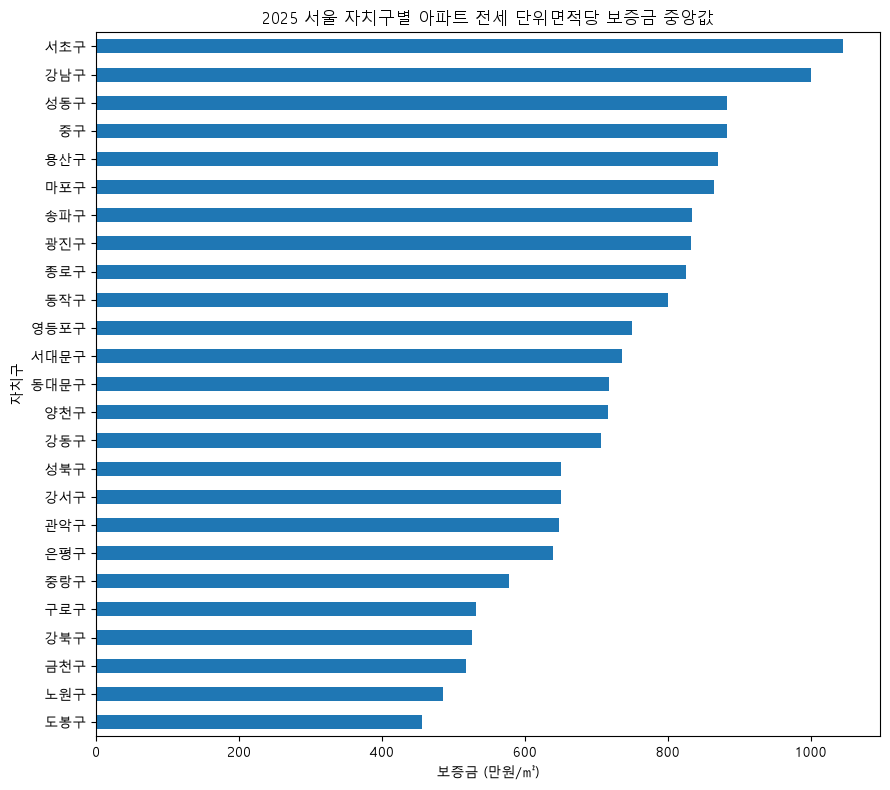

In [36]:
gu_plot = (
    jeonse_gu_2025["단위면적_중앙값"]
    .sort_values()
)

ax = gu_plot.plot(
    kind="barh",
    figsize=(9, 8)
)

ax.set_title(
    "2025 서울 자치구별 아파트 전세 단위면적당 보증금 중앙값"
)
ax.set_xlabel("보증금 (만원/㎡)")
ax.set_ylabel("자치구")

plt.tight_layout()
plt.show()

In [37]:
bins = [0, 40, 60, 85, 102, float("inf")]
labels = [
    "~40㎡",
    "40~60㎡",
    "60~85㎡",
    "85~102㎡",
    "102㎡~"
]

df_jeonse["area_group"] = pd.cut(
    df_jeonse["임대면적"],
    bins=bins,
    labels=labels,
    right=False
)

df_jeonse["area_group"].value_counts().sort_index()

area_group
~40㎡        32481
40~60㎡     184682
60~85㎡     215962
85~102㎡     15094
102㎡~       57266
Name: count, dtype: int64

In [38]:
jeonse_60_85 = df_jeonse[
    df_jeonse["area_group"] == "60~85㎡"
].copy()

jeonse_60_85.shape

(215962, 28)

In [39]:
gu_60_85_2025 = (
    jeonse_60_85[
        jeonse_60_85["contract_year"] == 2025
    ]
    .groupby("자치구명")
    .agg(
        거래건수=("보증금(만원)", "count"),
        보증금_중앙값=("보증금(만원)", "median"),
        단위면적_중앙값=("deposit_per_m2", "median")
    )
    .sort_values(
        "보증금_중앙값",
        ascending=False
    )
)

gu_60_85_2025

,거래건수,보증금_중앙값,단위면적_중앙값
자치구명,,,
서초구,6859,89200.0,1063.704054
강남구,7869,80000.0,976.815347
종로구,813,70100.0,883.333333
마포구,4650,70000.0,844.440765
성동구,4769,70000.0,826.348719
용산구,1837,70000.0,824.693685
송파구,10338,69300.0,825.082520
중구,1167,68000.0,803.357032
광진구,2688,67200.0,812.051312


In [40]:
gu_60_85_change = (
    jeonse_60_85[
        jeonse_60_85["contract_year"].isin([2023, 2025])
    ]
    .groupby(
        ["자치구명", "contract_year"]
    )["보증금(만원)"]
    .median()
    .unstack()
)

gu_60_85_change["변화율(%)"] = (
    (gu_60_85_change[2025] / gu_60_85_change[2023] - 1)
    * 100
)

gu_60_85_change.sort_values(
    "변화율(%)",
    ascending=False
).round(1)

contract_year,2023,2025,변화율(%)
자치구명,,,
서초구,75000.0,89200.0,18.9
강서구,46000.0,54000.0,17.4
용산구,60000.0,70000.0,16.7
서대문구,51000.0,59000.0,15.7
송파구,60000.0,69300.0,15.5
강동구,50000.0,57500.0,15.0
마포구,61000.0,70000.0,14.8
영등포구,50000.0,57225.0,14.5
강남구,70000.0,80000.0,14.3


In [41]:
df_jeonse_age = df_jeonse[
    df_jeonse["has_build_year"]
].copy()

df_jeonse_age.shape

(505418, 28)

In [42]:
age_bins = [-1, 5, 10, 20, 30, float("inf")]
age_labels = [
    "0~4년",
    "5~9년",
    "10~19년",
    "20~29년",
    "30년 이상"
]

df_jeonse_age["age_group"] = pd.cut(
    df_jeonse_age["building_age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

df_jeonse_age["age_group"].value_counts().sort_index()

age_group
0~4년       55178
5~9년       63234
10~19년    110105
20~29년    140476
30년 이상    136425
Name: count, dtype: int64

In [43]:
age_price_2025 = (
    df_jeonse_age[
        df_jeonse_age["contract_year"] == 2025
    ]
    .groupby(
        "age_group",
        observed=True
    )
    .agg(
        거래건수=("보증금(만원)", "count"),
        보증금_중앙값=("보증금(만원)", "median"),
        단위면적_중앙값=("deposit_per_m2", "median")
    )
)

age_price_2025

,거래건수,보증금_중앙값,단위면적_중앙값
age_group,,,
0~4년,23390,65100.0,988.467875
5~9년,32296,67500.0,971.529667
10~19년,49189,60000.0,776.790443
20~29년,67360,50000.0,673.743088
30년 이상,66335,40000.0,592.712966


In [44]:
age_year_price = (
    df_jeonse_age
    .groupby(
        ["age_group", "contract_year"],
        observed=True
    )["deposit_per_m2"]
    .median()
    .unstack()
)

age_year_price.round(1)

contract_year,2023,2024,2025
age_group,,,
0~4년,847.6,941.4,988.5
5~9년,854.3,964.8,971.5
10~19년,649.8,730.3,776.8
20~29년,589.3,659.8,673.7
30년 이상,531.2,576.0,592.7


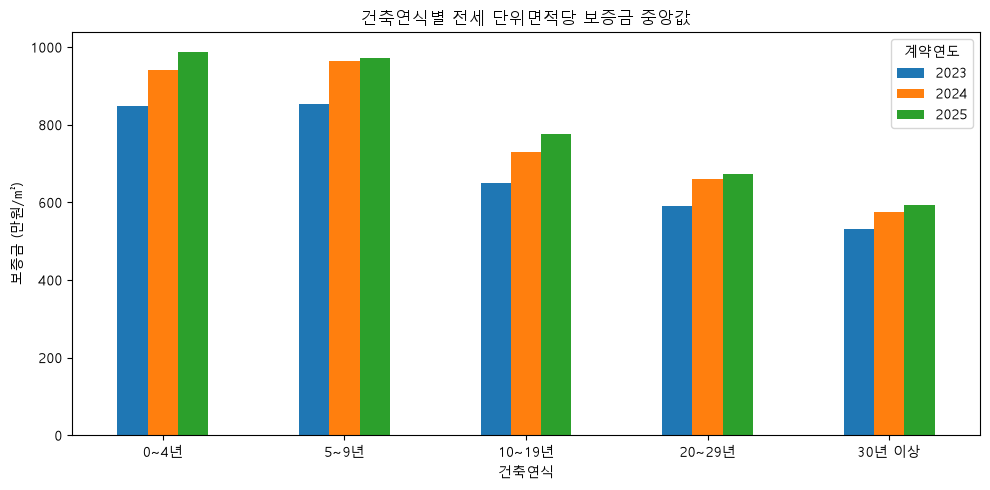

In [45]:
ax = age_year_price.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("건축연식별 전세 단위면적당 보증금 중앙값")
ax.set_xlabel("건축연식")
ax.set_ylabel("보증금 (만원/㎡)")
ax.legend(title="계약연도")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
age_compare = df_jeonse_age[
    (df_jeonse_age["contract_year"] == 2025)
    & (df_jeonse_age["area_group"] == "60~85㎡")
].copy()

In [47]:
def classify_age(age):
    if 0 <= age < 10:
        return "신축(0~9년)"
    elif age >= 20:
        return "구축(20년 이상)"
    else:
        return "기타"

age_compare["age_type"] = (
    age_compare["building_age"]
    .apply(classify_age)
)

In [48]:
age_compare = age_compare[
    age_compare["age_type"].isin(
        ["신축(0~9년)", "구축(20년 이상)"]
    )
].copy()

In [49]:
age_gu_counts = (
    age_compare
    .groupby(["자치구명", "age_type"])
    .size()
    .unstack(fill_value=0)
)

age_gu_counts

age_type,구축(20년 이상),신축(0~9년)
자치구명,,
강남구,4669,1435
강동구,2497,2993
강북구,781,186
강서구,2610,847
관악구,1676,384
광진구,2109,389
구로구,2504,240
금천구,549,266
노원구,3897,522


In [50]:
age_gu_price = (
    age_compare
    .groupby(
        ["자치구명", "age_type"]
    )["deposit_per_m2"]
    .median()
    .unstack()
)

age_gu_price

age_type,구축(20년 이상),신축(0~9년)
자치구명,,
강남구,904.180366,1658.960150
강동구,593.612727,917.679448
강북구,471.031559,624.484514
강서구,579.981320,803.130148
관악구,612.052731,830.269244
광진구,767.703508,1107.848372
구로구,506.120527,560.972352
금천구,447.743608,746.083064
노원구,529.536361,679.419758


In [51]:
valid_gu = age_gu_counts[
    (age_gu_counts["신축(0~9년)"] >= 30)
    & (age_gu_counts["구축(20년 이상)"] >= 30)
].index

age_gu_price_valid = (
    age_gu_price.loc[valid_gu].copy()
)

In [52]:
age_gu_price_valid["신축프리미엄(%)"] = (
    (
        age_gu_price_valid["신축(0~9년)"]
        / age_gu_price_valid["구축(20년 이상)"]
        - 1
    )
    * 100
)

age_gu_price_valid = (
    age_gu_price_valid
    .sort_values(
        "신축프리미엄(%)",
        ascending=False
    )
)

age_gu_price_valid.round(1)

age_type,구축(20년 이상),신축(0~9년),신축프리미엄(%)
자치구명,,,
도봉구,435.9,1040.1,138.6
서초구,897.3,1766.2,96.8
종로구,655.3,1268.7,93.6
강남구,904.2,1659.0,83.5
금천구,447.7,746.1,66.6
은평구,461.8,733.9,58.9
마포구,729.8,1136.7,55.8
강동구,593.6,917.7,54.6
성동구,728.4,1118.2,53.5


동일 자치구와 60~85㎡ 면적 조건에서도 모든 자치구에서 신축 아파트의 단위면적당 전세보증금 중앙값이 구축보다 높게 나타났다. 다만 단지별 입지·브랜드 등 미통제 요인이 존재하므로 이를 건축연식의 인과효과로 해석하지 않는다. 이후 다중회귀 분석을 통해 다른 변수들을 함께 통제한다.

In [53]:
df_monthly = df_eda[
    (df_eda["전월세구분"] == "월세")
    & (df_eda["valid_monthly_rent"])
].copy()

df_monthly.shape

(370367, 27)

In [54]:
df_monthly[
    [
        "보증금(만원)",
        "임대료(만원)",
        "임대면적"
    ]
].describe()

,보증금(만원),임대료(만원),임대면적
count,370367.000000,370367.000000,370367.000000
mean,20314.575572,108.876047,60.569863
std,25707.104788,123.064740,30.917491
min,0.000000,1.000000,9.040000
25%,4792.000000,35.000000,39.160000
50%,10000.000000,75.000000,59.760000
75%,29700.000000,145.000000,84.770000
max,810000.000000,9600.000000,314.800000


In [55]:
monthly_corr = df_monthly[
    [
        "보증금(만원)",
        "임대료(만원)"
    ]
].corr(
    method="spearman"
)

monthly_corr

,보증금(만원),임대료(만원)
보증금(만원),1.000000,0.173693
임대료(만원),0.173693,1.000000


In [56]:
df_monthly_60_85 = df_monthly[
    (df_monthly["임대면적"] >= 60)
    & (df_monthly["임대면적"] < 85)
].copy()

df_monthly_60_85.shape

(99650, 27)

In [57]:
monthly_60_85_corr = df_monthly_60_85[
    [
        "보증금(만원)",
        "임대료(만원)"
    ]
].corr(
    method="spearman"
)

monthly_60_85_corr

,보증금(만원),임대료(만원)
보증금(만원),1.000000,-0.333399
임대료(만원),-0.333399,1.000000


In [58]:
deposit_bins = [
    0,
    5000,
    10000,
    20000,
    30000,
    50000,
    100000,
    float("inf")
]

deposit_labels = [
    "5천 미만",
    "5천~1억",
    "1~2억",
    "2~3억",
    "3~5억",
    "5~10억",
    "10억 이상"
]

df_monthly_60_85["deposit_group"] = pd.cut(
    df_monthly_60_85["보증금(만원)"],
    bins=deposit_bins,
    labels=deposit_labels,
    right=False
)

In [59]:
deposit_rent_summary = (
    df_monthly_60_85
    .groupby(
        "deposit_group",
        observed=True
    )
    .agg(
        거래건수=("임대료(만원)", "count"),
        보증금_중앙값=("보증금(만원)", "median"),
        월세_중앙값=("임대료(만원)", "median")
    )
)

deposit_rent_summary

,거래건수,보증금_중앙값,월세_중앙값
deposit_group,,,
5천 미만,5995,2000.0,120.0
5천~1억,10550,5000.0,160.0
1~2억,20278,10000.0,180.0
2~3억,16830,20000.0,120.0
3~5억,24261,35000.0,100.0
5~10억,19356,60000.0,94.0
10억 이상,2380,110000.0,115.5


In [60]:
monthly_60_85_corr = df_monthly_60_85[
    [
        "보증금(만원)",
        "임대료(만원)"
    ]
].corr(
    method="spearman"
)

monthly_60_85_corr

,보증금(만원),임대료(만원)
보증금(만원),1.000000,-0.333399
임대료(만원),-0.333399,1.000000


In [61]:
gu_monthly_corr = (
    df_monthly_60_85
    .groupby("자치구명")
    .apply(
        lambda x: x["보증금(만원)"].corr(
            x["임대료(만원)"],
            method="spearman"
        )
    )
    .sort_values()
)

gu_monthly_corr

자치구명
광진구    -0.699562
구로구    -0.659819
관악구    -0.626444
성북구    -0.615129
금천구    -0.613517
동대문구   -0.604831
강서구    -0.600910
중랑구    -0.600486
마포구    -0.600316
중구     -0.597681
용산구    -0.570746
성동구    -0.568235
강동구    -0.562728
동작구    -0.549263
양천구    -0.536384
강북구    -0.517645
서대문구   -0.517537
도봉구    -0.514205
은평구    -0.505879
강남구    -0.466183
종로구    -0.465858
송파구    -0.453045
영등포구   -0.426316
서초구    -0.401539
노원구    -0.379276
dtype: float64

In [62]:
gu_monthly_count = (
    df_monthly_60_85
    .groupby("자치구명")
    .size()
)

gu_monthly_summary = pd.DataFrame({
    "거래건수": gu_monthly_count,
    "Spearman": gu_monthly_corr
}).sort_values("Spearman")

gu_monthly_summary.round(3)

,거래건수,Spearman
자치구명,,
광진구,2406,-0.700
구로구,4274,-0.660
관악구,2198,-0.626
성북구,3397,-0.615
금천구,1825,-0.614
동대문구,3366,-0.605
강서구,3614,-0.601
중랑구,1724,-0.600
마포구,5153,-0.600


H5. 월세 계약에서는 보증금이 증가할수록 월세가 감소하는 경향이 존재한다.
전체 월세 계약에서는 보증금과 월세 사이에 약한 양의 상관관계가 나타났지만, 60~85㎡로 면적을 제한하고 자치구별로 분석한 결과 서울 25개 자치구 모두에서 음의 Spearman 상관관계가 나타났다. 이는 전체 데이터에서는 지역별 주택 가격 수준이 혼재되어 관계가 가려졌으며, 지역과 면적을 통제할 경우 보증금과 월세 사이의 trade-off가 보다 명확하게 나타남을 보여준다. 단, 이는 상관관계이며 인과효과를 의미하지 않는다.

In [63]:
monthly_60_85_corr

,보증금(만원),임대료(만원)
보증금(만원),1.000000,-0.333399
임대료(만원),-0.333399,1.000000


In [64]:
jeonse_quantiles = (
    df_jeonse["보증금(만원)"]
    .quantile([
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
)

jeonse_quantiles

0.01      9846.0
0.05     17000.0
0.25     35000.0
0.50     50000.0
0.75     70000.0
0.90     95000.0
0.95    120000.0
0.99    180000.0
Name: 보증금(만원), dtype: float64

In [65]:
monthly_quantiles = (
    df_monthly["임대료(만원)"]
    .quantile([
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
)

monthly_quantiles

0.01      5.0
0.05     10.0
0.25     35.0
0.50     75.0
0.75    145.0
0.90    240.0
0.95    317.0
0.99    550.0
Name: 임대료(만원), dtype: float64

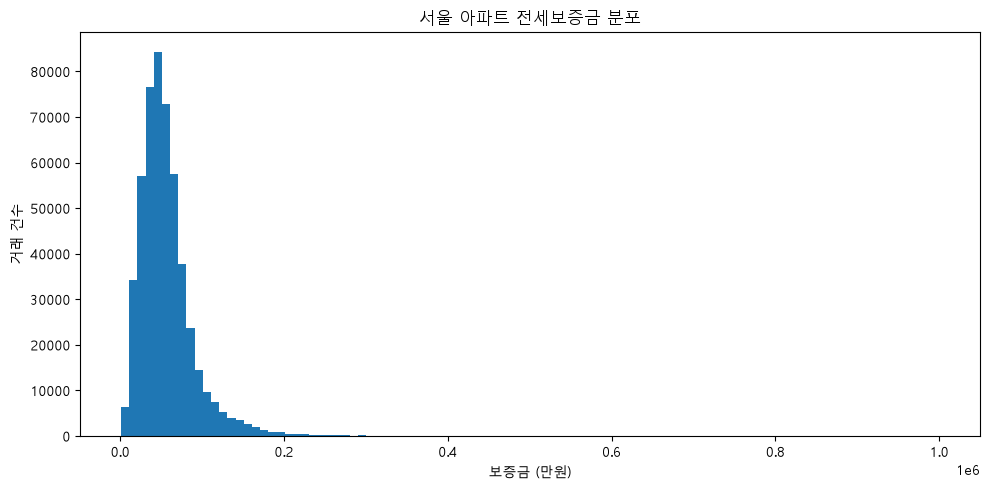

In [66]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_jeonse["보증금(만원)"],
    bins=100
)

plt.title("서울 아파트 전세보증금 분포")
plt.xlabel("보증금 (만원)")
plt.ylabel("거래 건수")

plt.tight_layout()
plt.show()

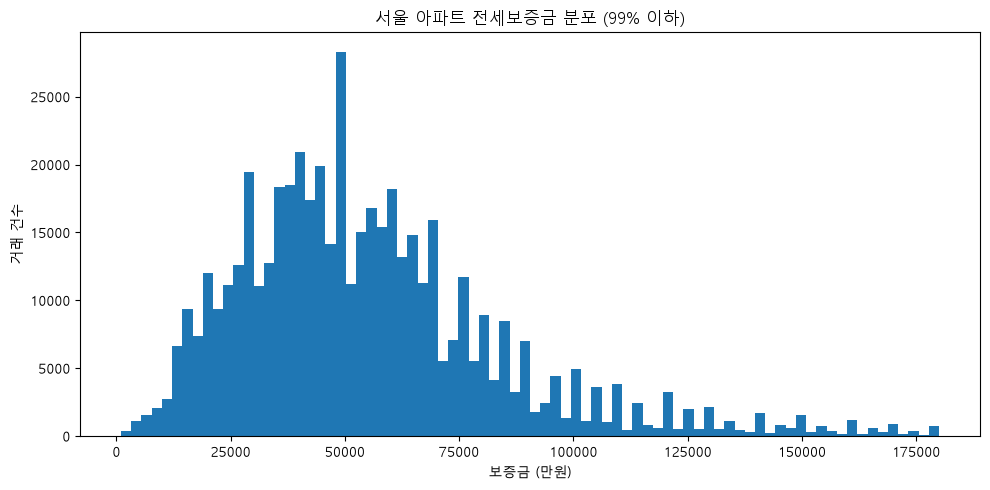

In [67]:
jeonse_p99 = (
    df_jeonse["보증금(만원)"]
    .quantile(0.99)
)

plt.figure(figsize=(10, 5))

plt.hist(
    df_jeonse.loc[
        df_jeonse["보증금(만원)"] <= jeonse_p99,
        "보증금(만원)"
    ],
    bins=80
)

plt.title("서울 아파트 전세보증금 분포 (99% 이하)")
plt.xlabel("보증금 (만원)")
plt.ylabel("거래 건수")

plt.tight_layout()
plt.show()

# EDA 주요 결과

## 1. 데이터 기간 및 거래량

분석 대상은 실제 계약일(contract_date)을 기준으로
2023-01-01 ~ 2025-12-31 사이의 서울 아파트 전월세 계약으로 제한하였다.

서울시 연도별 원본 파일은 계약연도가 아니라 접수년도를 기준으로 구성되어 있어,
파일 연도와 실제 계약연도가 일부 일치하지 않는 것을 확인하였다.

또한 2025년 거래 건수가 크게 증가하는 현상이 나타났지만,
신고·접수 데이터의 특성과 제도 변화 영향을 받을 수 있으므로
이를 실제 시장 거래량 증가로 직접 해석하지 않았다.

---

## 2. 전세가격 변화

서울 아파트 전세보증금 중앙값:

- 2023: 46,000만원
- 2024: 50,000만원
- 2025: 52,500만원

단위면적당 전세보증금 중앙값:

- 2023: 644.2만원/㎡
- 2024: 706.7만원/㎡
- 2025: 727.7만원/㎡

2023~2025년 동안 전세가격 수준이 상승하는 패턴이 관찰되었다.

---

## 3. 지역별 차이

2025년 단위면적당 전세보증금 중앙값은
서초구, 강남구, 성동구 등에서 높은 수준을 보였다.

2023년과 2025년을 비교한 결과
25개 자치구 모두 단위면적당 전세보증금 중앙값이 상승하였다.

60~85㎡로 면적을 제한한 분석에서도
모든 자치구의 보증금 중앙값이 상승하여,
단순한 면적 구성 변화만으로는 가격 상승 패턴을 설명하기 어려웠다.

---

## 4. 건축연식

2025년 단위면적당 전세보증금 중앙값:

- 0~4년: 988.5만원/㎡
- 5~9년: 971.5만원/㎡
- 10~19년: 776.8만원/㎡
- 20~29년: 673.7만원/㎡
- 30년 이상: 592.7만원/㎡

동일 자치구와 60~85㎡ 조건으로 제한한 분석에서도
모든 자치구에서 신축(0~9년)의 가격이 구축(20년 이상)보다 높았다.

다만 지역 내 세부 입지, 브랜드, 학군 등의 변수가 통제되지 않았으므로
이를 건축연식의 인과효과로 해석하지 않는다.

---

## 5. 보증금과 월세 관계

전체 월세 데이터에서 보증금과 월세의 Spearman 상관계수는
약 +0.17로 약한 양의 관계가 나타났다.

그러나 60~85㎡로 면적을 제한하고 자치구별로 분석한 결과,
서울 25개 자치구 모두에서 음의 상관관계가 나타났다.

이는 전체 데이터에서는 지역별 주택 가격 수준이 혼재되어
보증금과 월세 간 관계가 가려질 수 있음을 보여준다.

같은 지역과 유사한 면적 조건에서는
보증금이 증가할수록 월세가 감소하는 trade-off가 관찰되었다.

---

## 6. 가격 분포

전세보증금:

- 중앙값: 50,000만원
- 95 percentile: 120,000만원
- 99 percentile: 180,000만원

월세:

- 중앙값: 75만원
- 95 percentile: 317만원
- 99 percentile: 550만원

가격 데이터는 오른쪽 꼬리가 긴 분포를 보여
극단적인 고가 거래가 평균값에 큰 영향을 줄 수 있다.

따라서 이후 분석에서는 중앙값을 주요 대표값으로 사용하며,
고가 거래는 명백한 오류가 아닌 이상 임의로 제거하지 않는다.